In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import uproot
import matplotlib
import h5py

font = {'weight' : 'bold',
        'size'   : 23}

matplotlib.rc('font', **font)
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
warnings.filterwarnings("ignore", message="numpy.ufunc size changed")


In [2]:
def GetInfo(filePath):
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

def Speeds(paths):
    ## No EL ---- 
    _10bar_NoEL_G4=paths[0]
    _10bar_NoEL_Opticks=paths[1]
    __10bar_NoEL_G4=GetInfo(_10bar_NoEL_G4)["MC"]
    __10bar_NoEL_Opticks=GetInfo(_10bar_NoEL_Opticks)["MC"]
    
    Energies=__10bar_NoEL_G4["particles"]["kin_energy"]
    
    plt.figure(figsize=(6,4),dpi=300)
    plt.title("NO Photons Comparison")
    plt.scatter(Energies,__10bar_NoEL_G4["Timing"]["time"],label="G4")
    plt.scatter(Energies,__10bar_NoEL_Opticks["Timing"]["time"],label="Opticks")
    plt.legend()
    plt.semilogy()
    plt.show()
    
    _10bar_G4=paths[2]
    _10barSkip0_Opticks=paths[3]

    __10barSkip0_Opticks=GetInfo(_10barSkip0_Opticks)["MC"]
    __10bar_G4=GetInfo(_10bar_G4)["MC"]
    plt.figure(figsize=(6,4),dpi=300)
    plt.title("With_Photons")
    plt.scatter(Energies,__10bar_G4["Timing"]["time"],label="G4")
    plt.scatter(Energies,__10barSkip0_Opticks["Timing"]["time"],label="Opticks")
    plt.semilogy()
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4),dpi=300)
    plt.title("With_Photons")
    plt.scatter(Energies,__10bar_NoEL_G4["Timing"]["time"]/__10bar_G4["Timing"]["time"],label="G4")
    plt.scatter(Energies,__10bar_NoEL_Opticks["Timing"]["time"]/__10barSkip0_Opticks["Timing"]["time"],label="Opticks")
    plt.legend()
    plt.show()

    Means=np.array([np.mean(__10bar_NoEL_G4["Timing"]["time"]/__10bar_G4["Timing"]["time"]),np.mean(__10bar_NoEL_Opticks["Timing"]["time"]/__10barSkip0_Opticks["Timing"]["time"])])*100
    Std=np.array([np.std(__10bar_NoEL_G4["Timing"]["time"]/__10bar_G4["Timing"]["time"]),np.std(__10bar_NoEL_Opticks["Timing"]["time"]/__10barSkip0_Opticks["Timing"]["time"])])*100
    print(f"Means {Means} STD {Std}")
    Percentages=[__10bar_NoEL_G4["Timing"]["time"]/__10bar_G4["Timing"]["time"],__10bar_NoEL_G4["Timing"]["time"]/__10barSkip0_Opticks["Timing"]["time"]]
    return Energies,Means,Std,Percentages,[__10bar_NoEL_G4["Timing"]["time"],__10bar_G4["Timing"]["time"],__10bar_NoEL_Opticks["Timing"]["time"],__10barSkip0_Opticks["Timing"]["time"]]

    

# ---- 3060TI ----

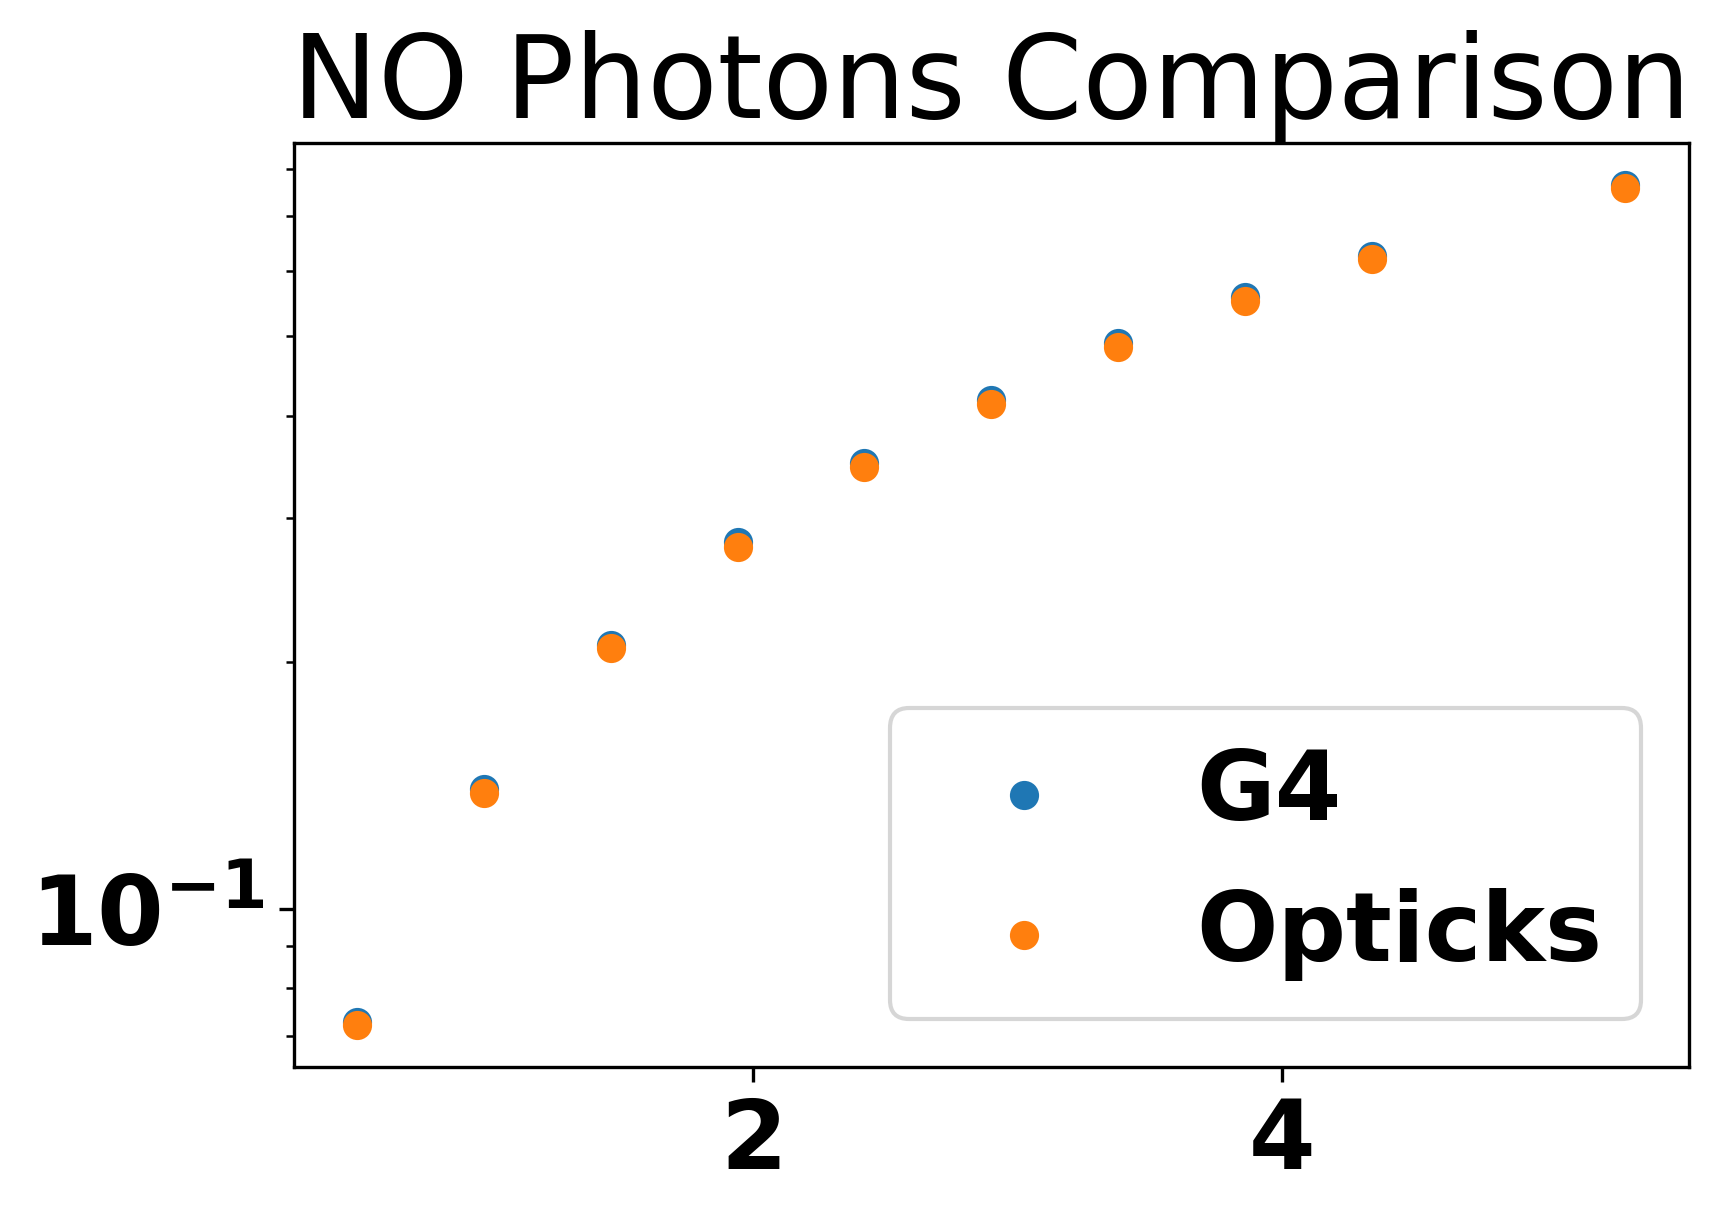

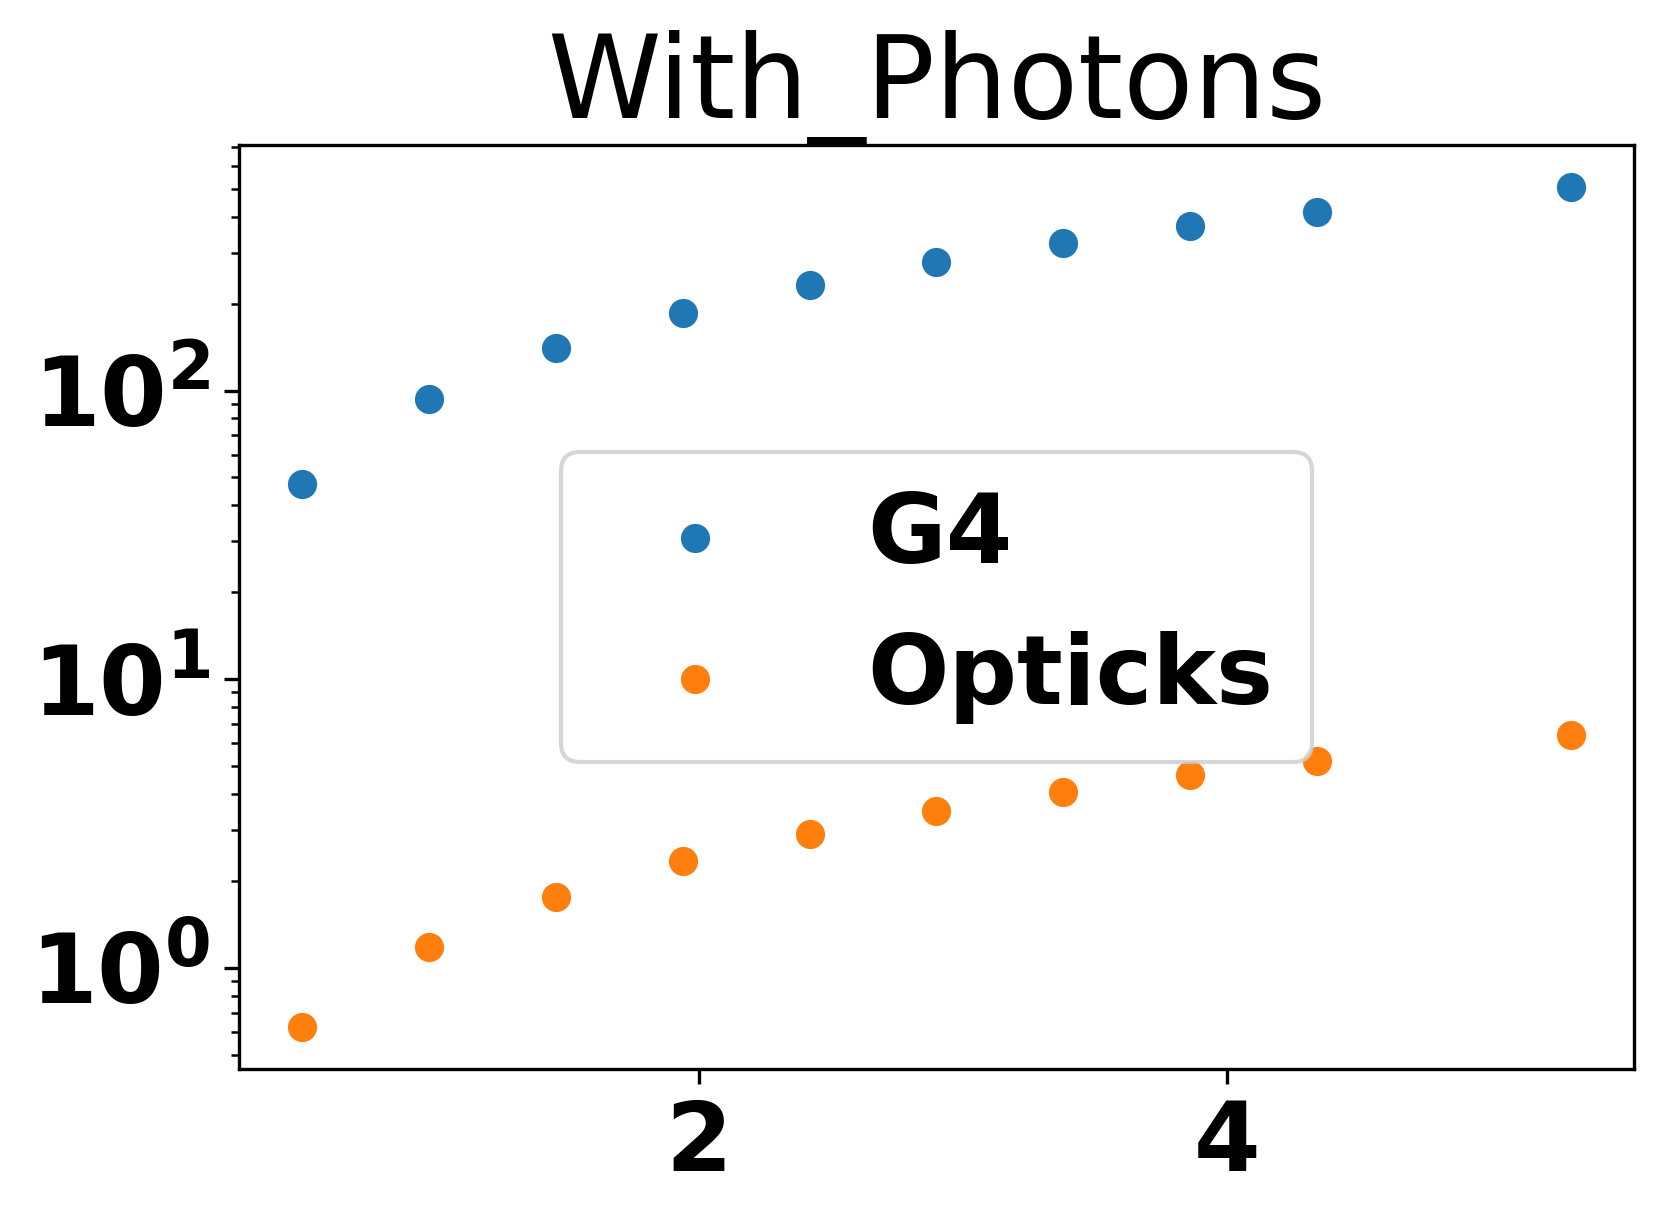

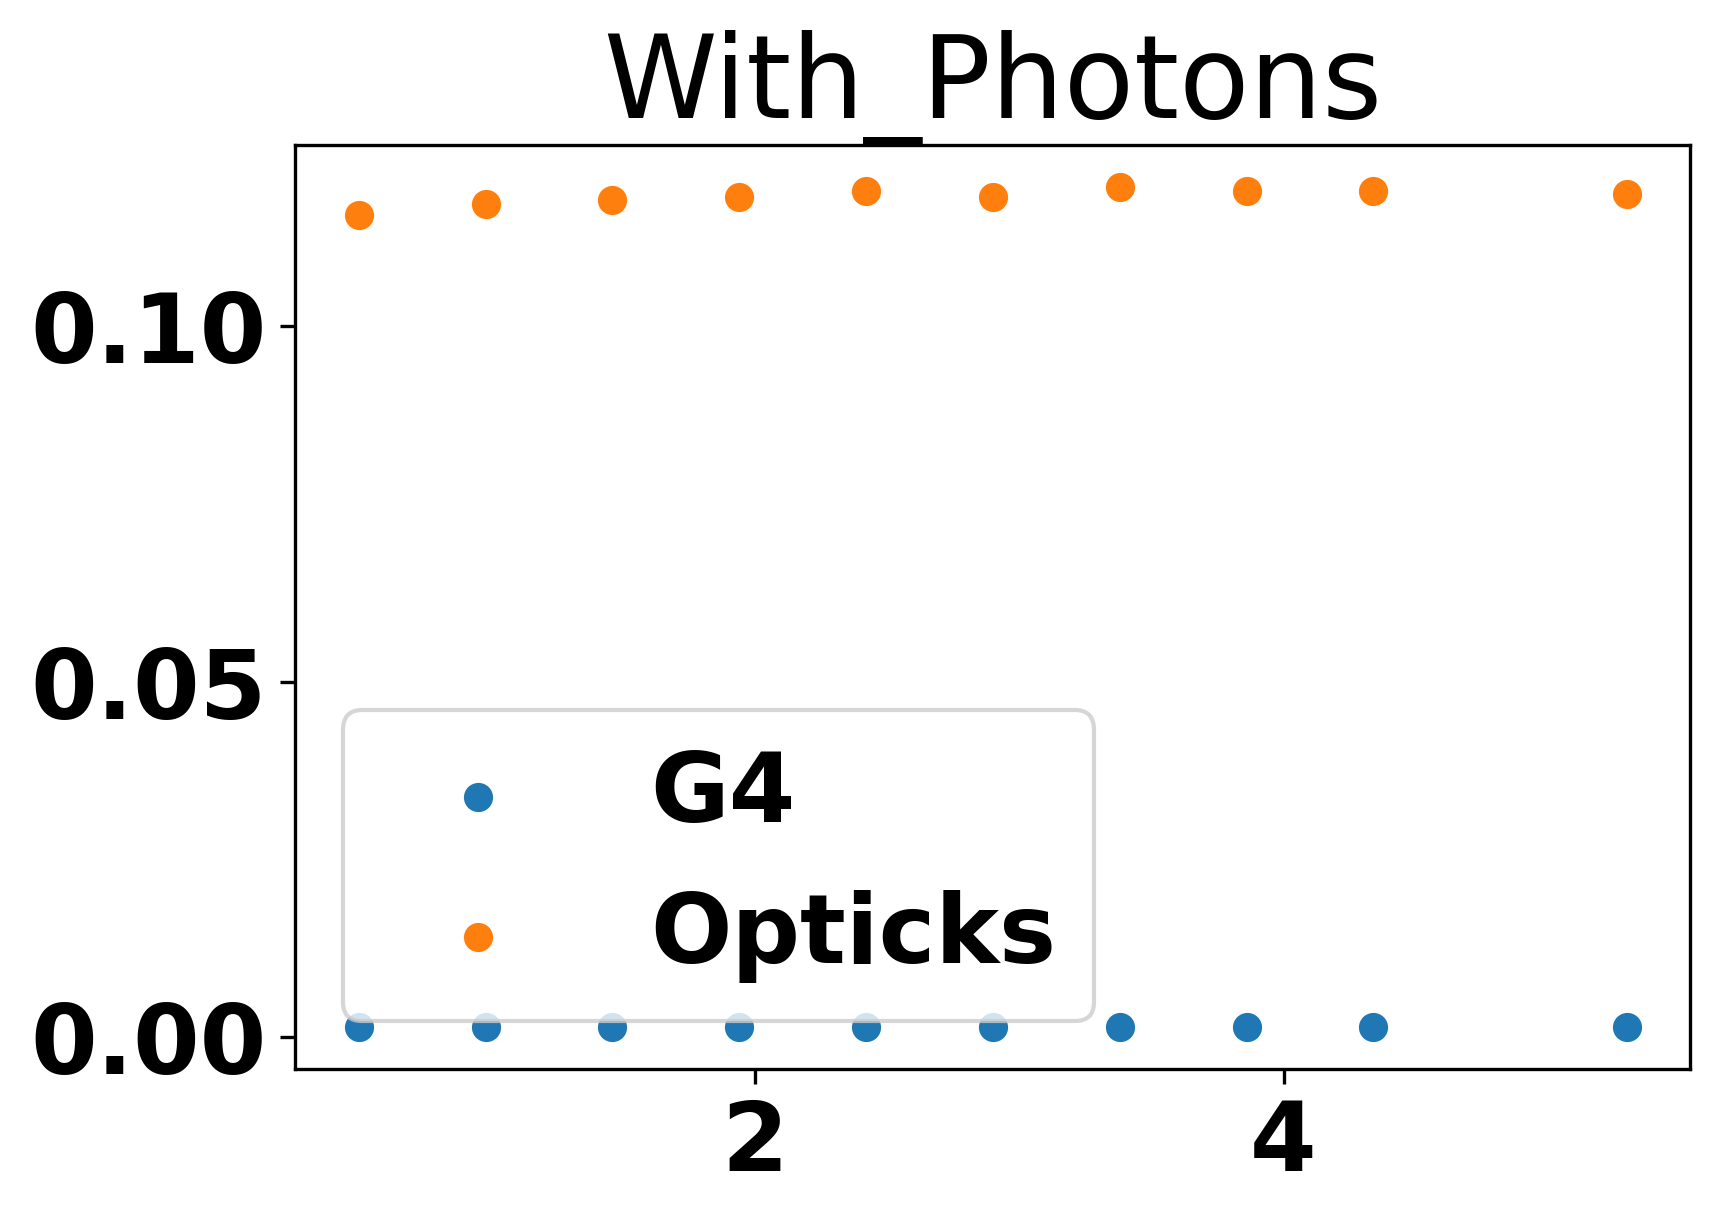

Means [ 0.15081997 11.82329335] STD [0.00118707 0.10934809]


In [3]:
MainPath="Performance/3060TI/SpeedTest"
paths=[f"{MainPath}/SpeedTest_10Events_10bar_G4_No_EL.h5",f"{MainPath}/SpeedTest_10Events_10bar_Opticks_No_EL.h5",f"{MainPath}/SpeedTest_10Events_10bar_G4.h5",f"{MainPath}/SpeedTest_10Events_10bar_Opticks_Skip0.h5"]
__3060TI=Speeds(paths)

# --- RTX-4090 ----

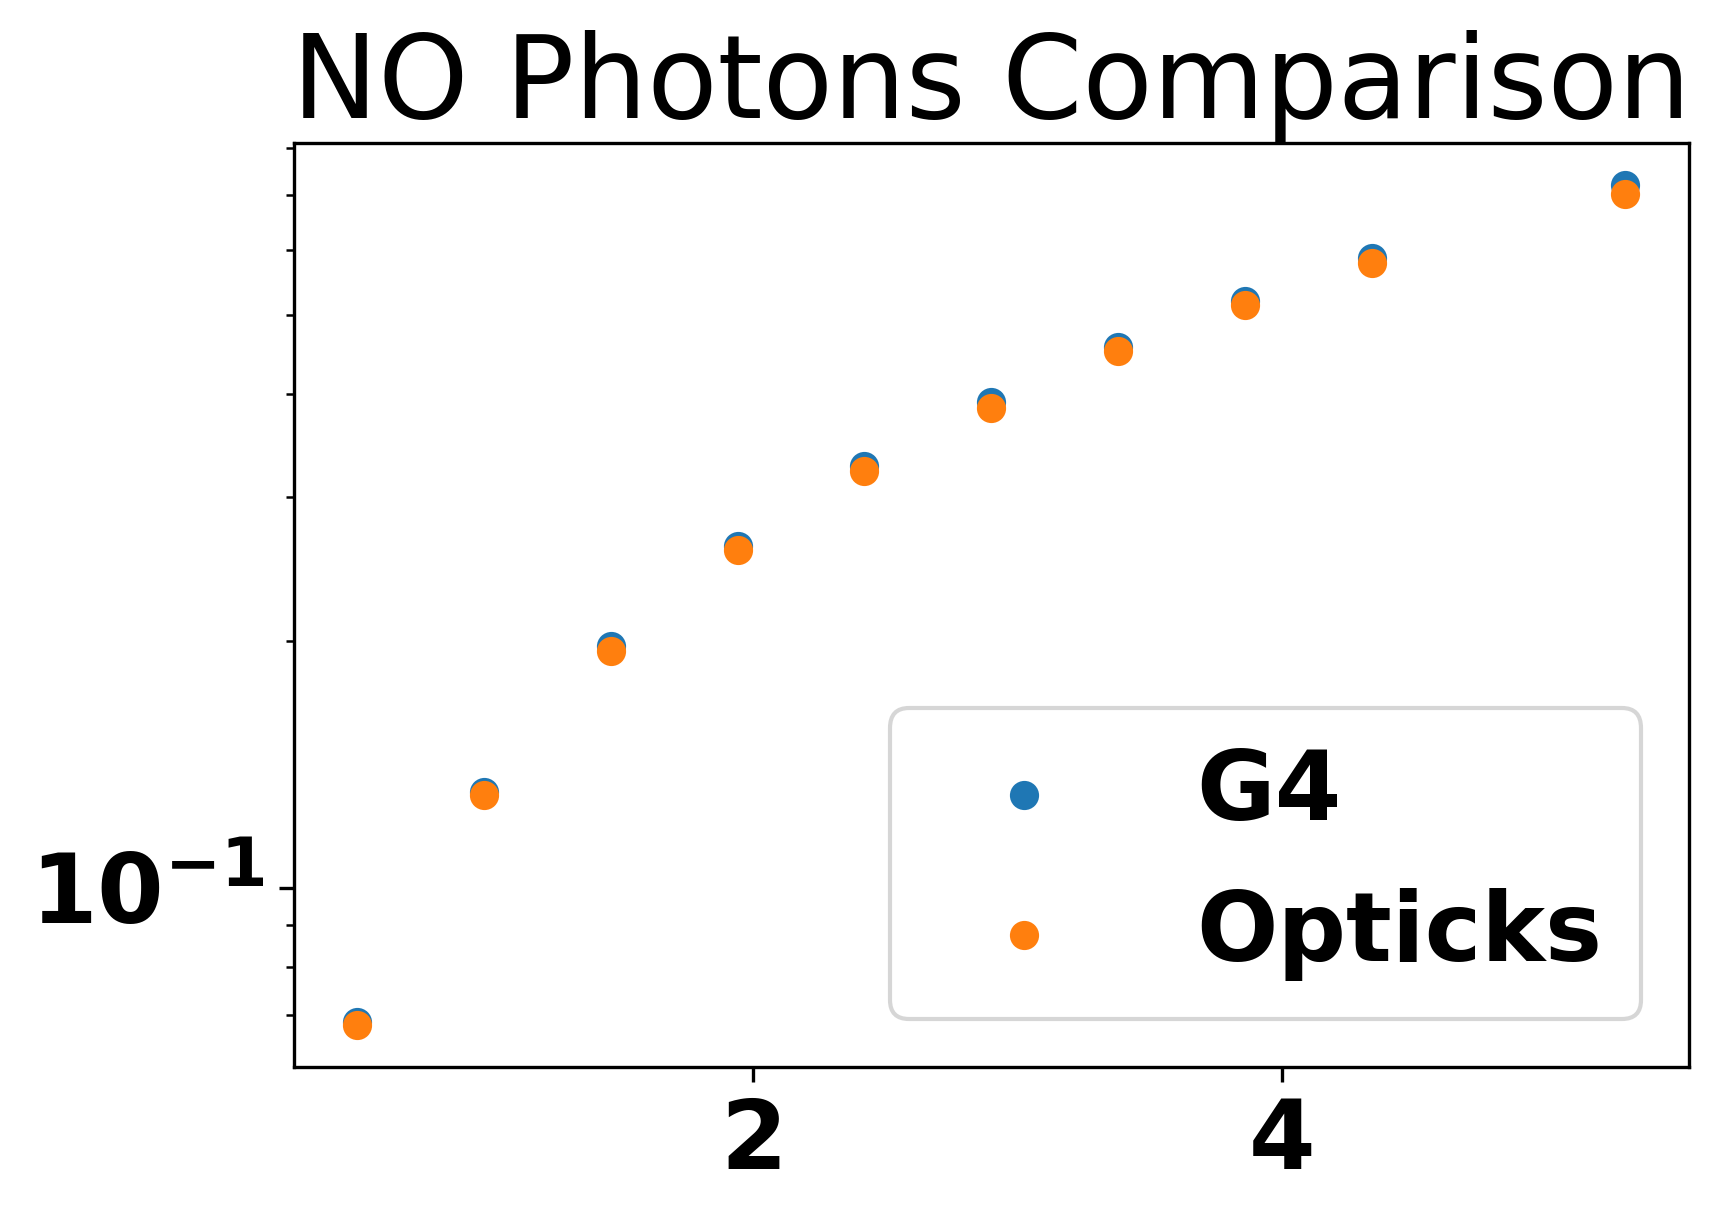

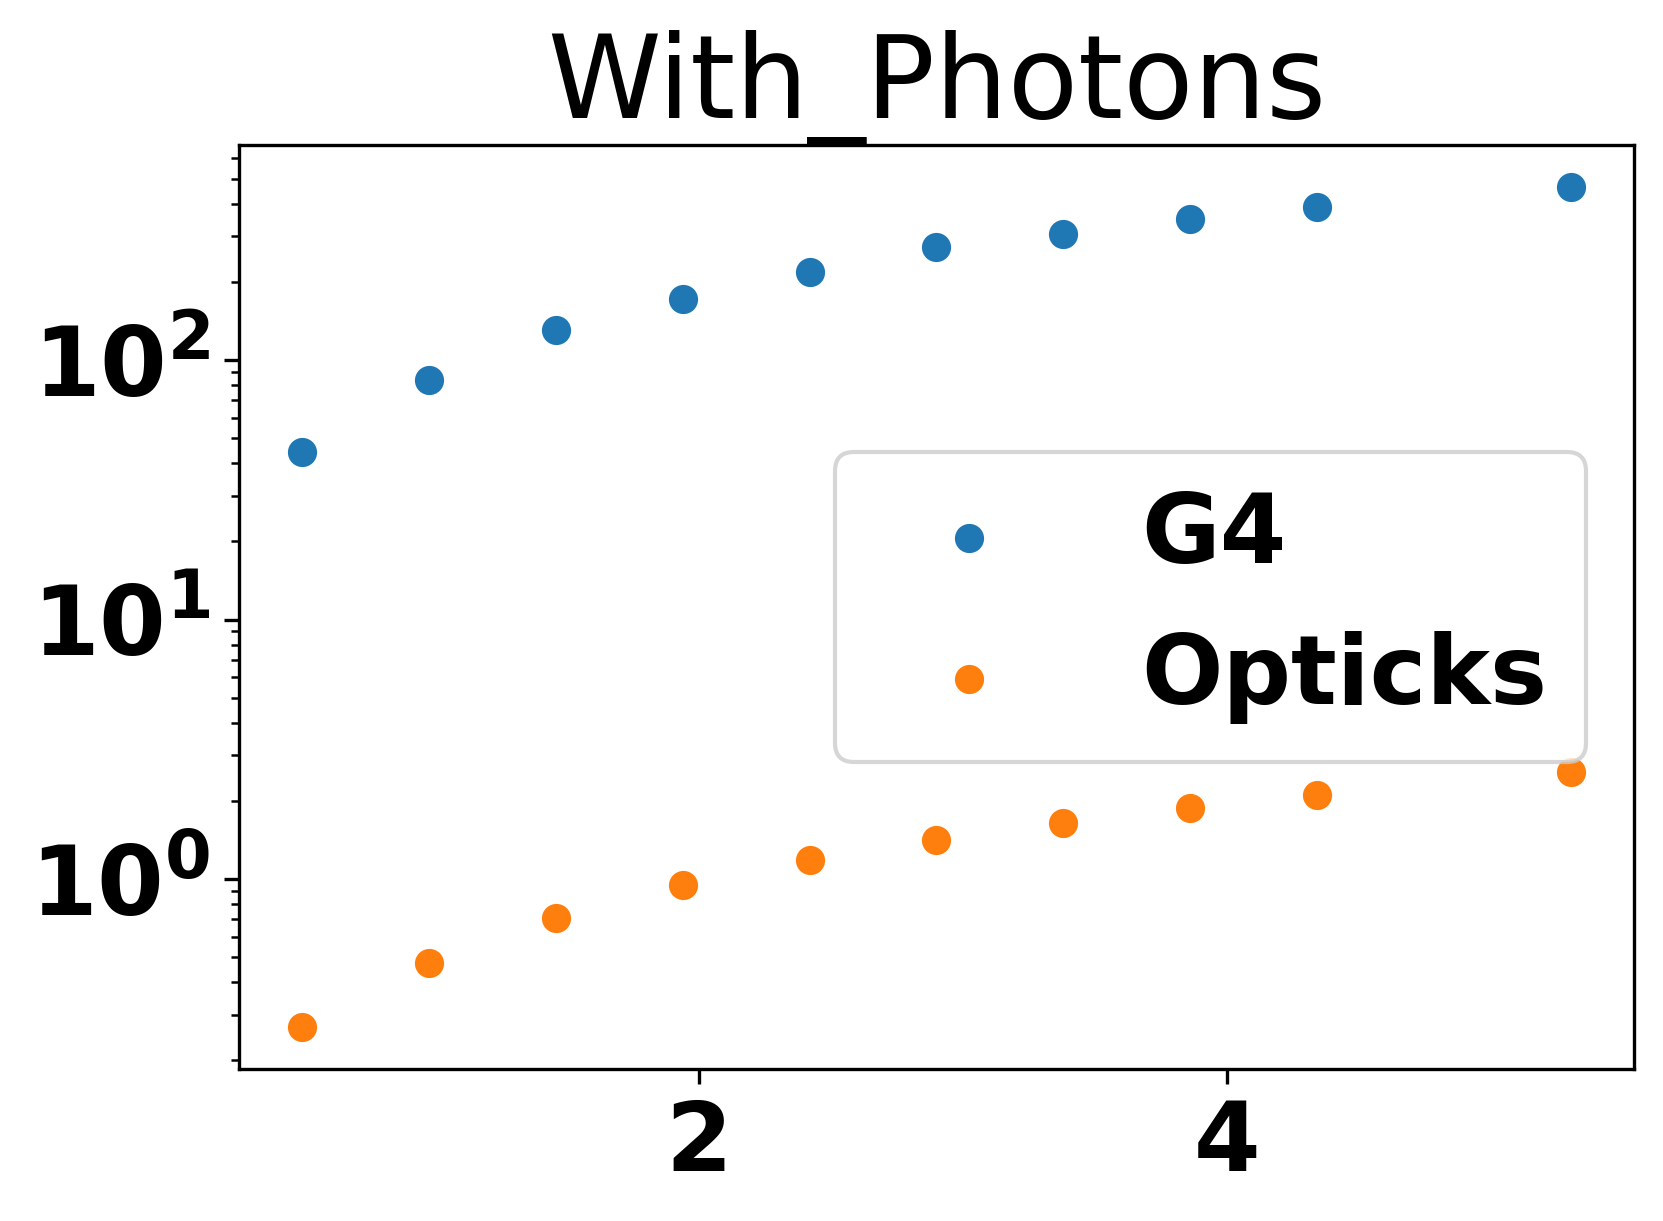

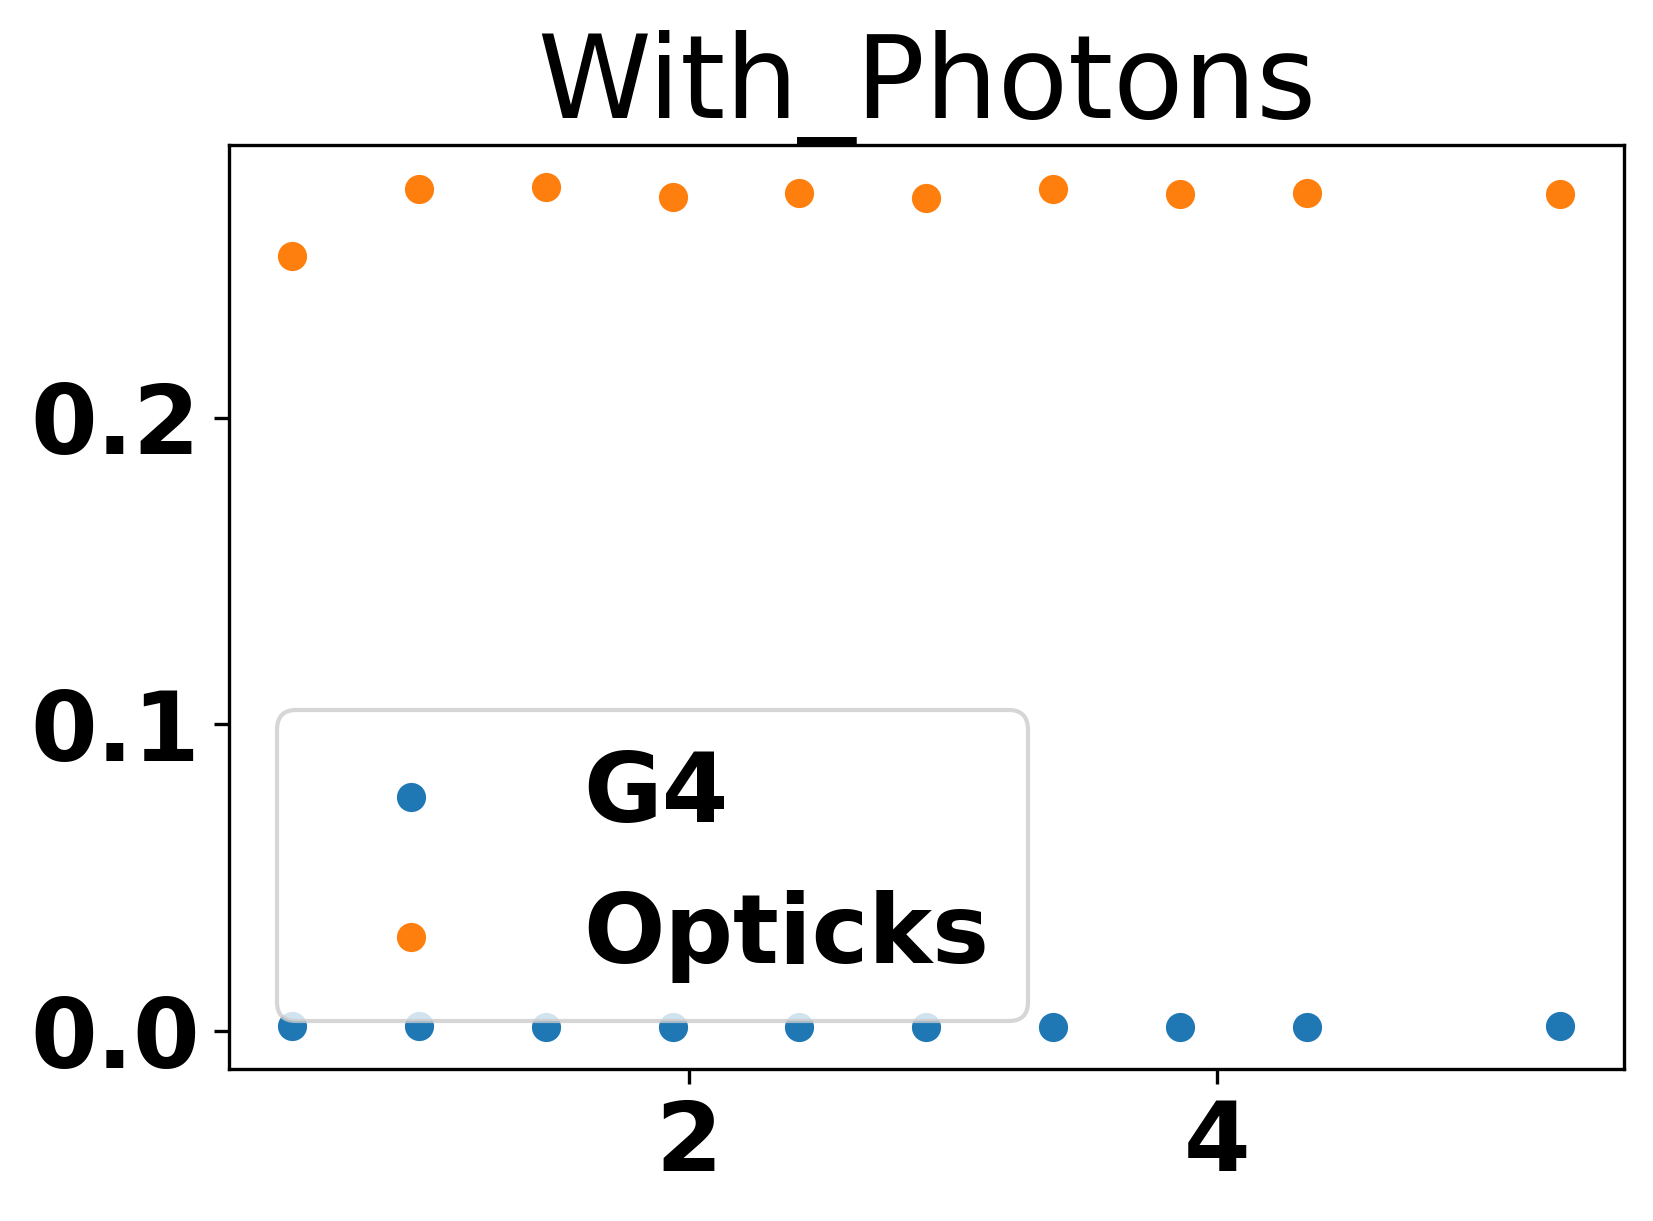

Means [ 0.1510935  27.12562986] STD [0.00349884 0.63129796]


In [4]:
MainPath="Performance/RTX-4090/SpeedTest"
#paths=[f"{MainPath}/SpeedTest_10Events_G4_10bar_No_EL.h5",f"{MainPath}/SpeedTest_10Events_Opticks_6bar_No_EL.h5",f"{MainPath}/SpeedTest_10Events_G4_10bar.h5",f"{MainPath}/SpeedTest_10Events_Opticks_10bar_Skip0.h5"]
paths=[f"{MainPath}/_SpeedTest_10Events_G4_10bar_NoEL.h5",f"{MainPath}/SpeedTest_10Events_Opticks_10bar_NoEL.h5",f"{MainPath}/SpeedTest_10Events_G4_10bar.h5",f"{MainPath}/_SpeedTest_10Events_Opticks_10bar_Skip0.h5"]

RTX_4090=Speeds(paths)

# --- Laptop ----

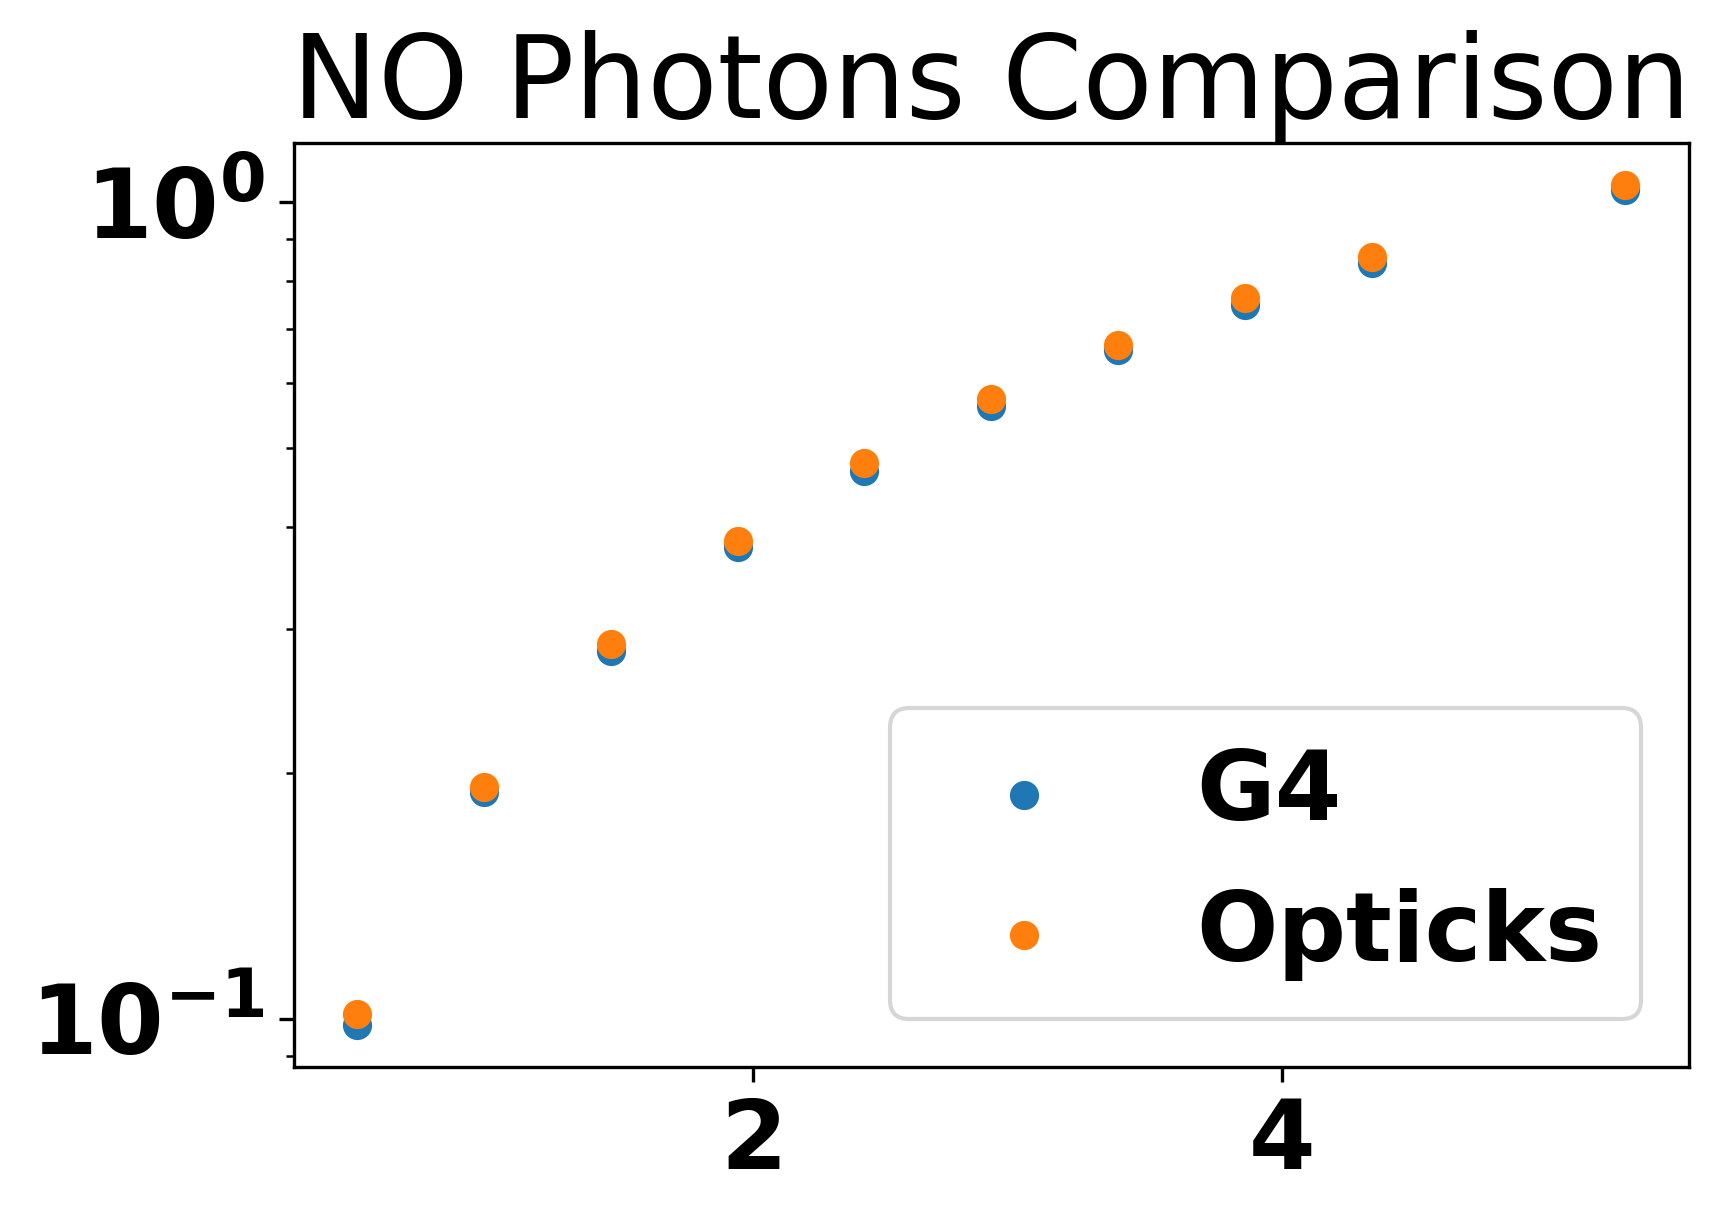

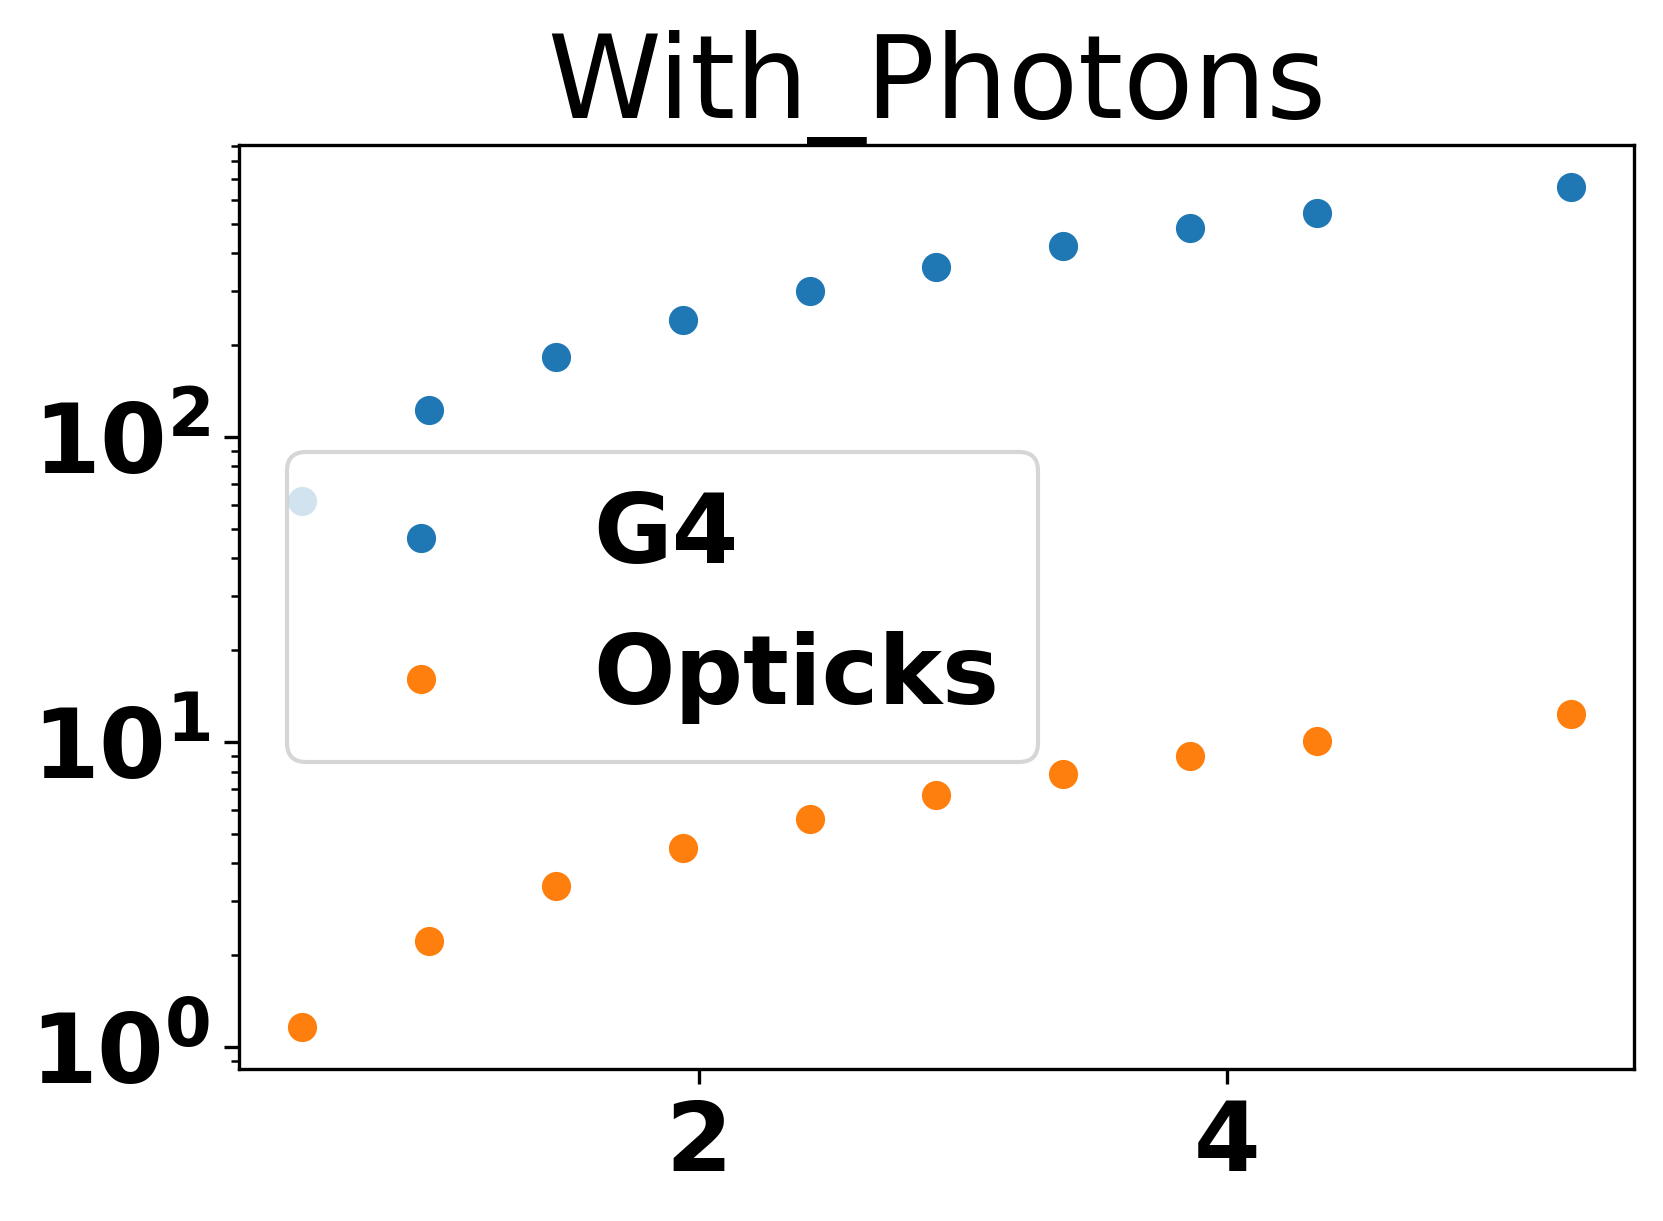

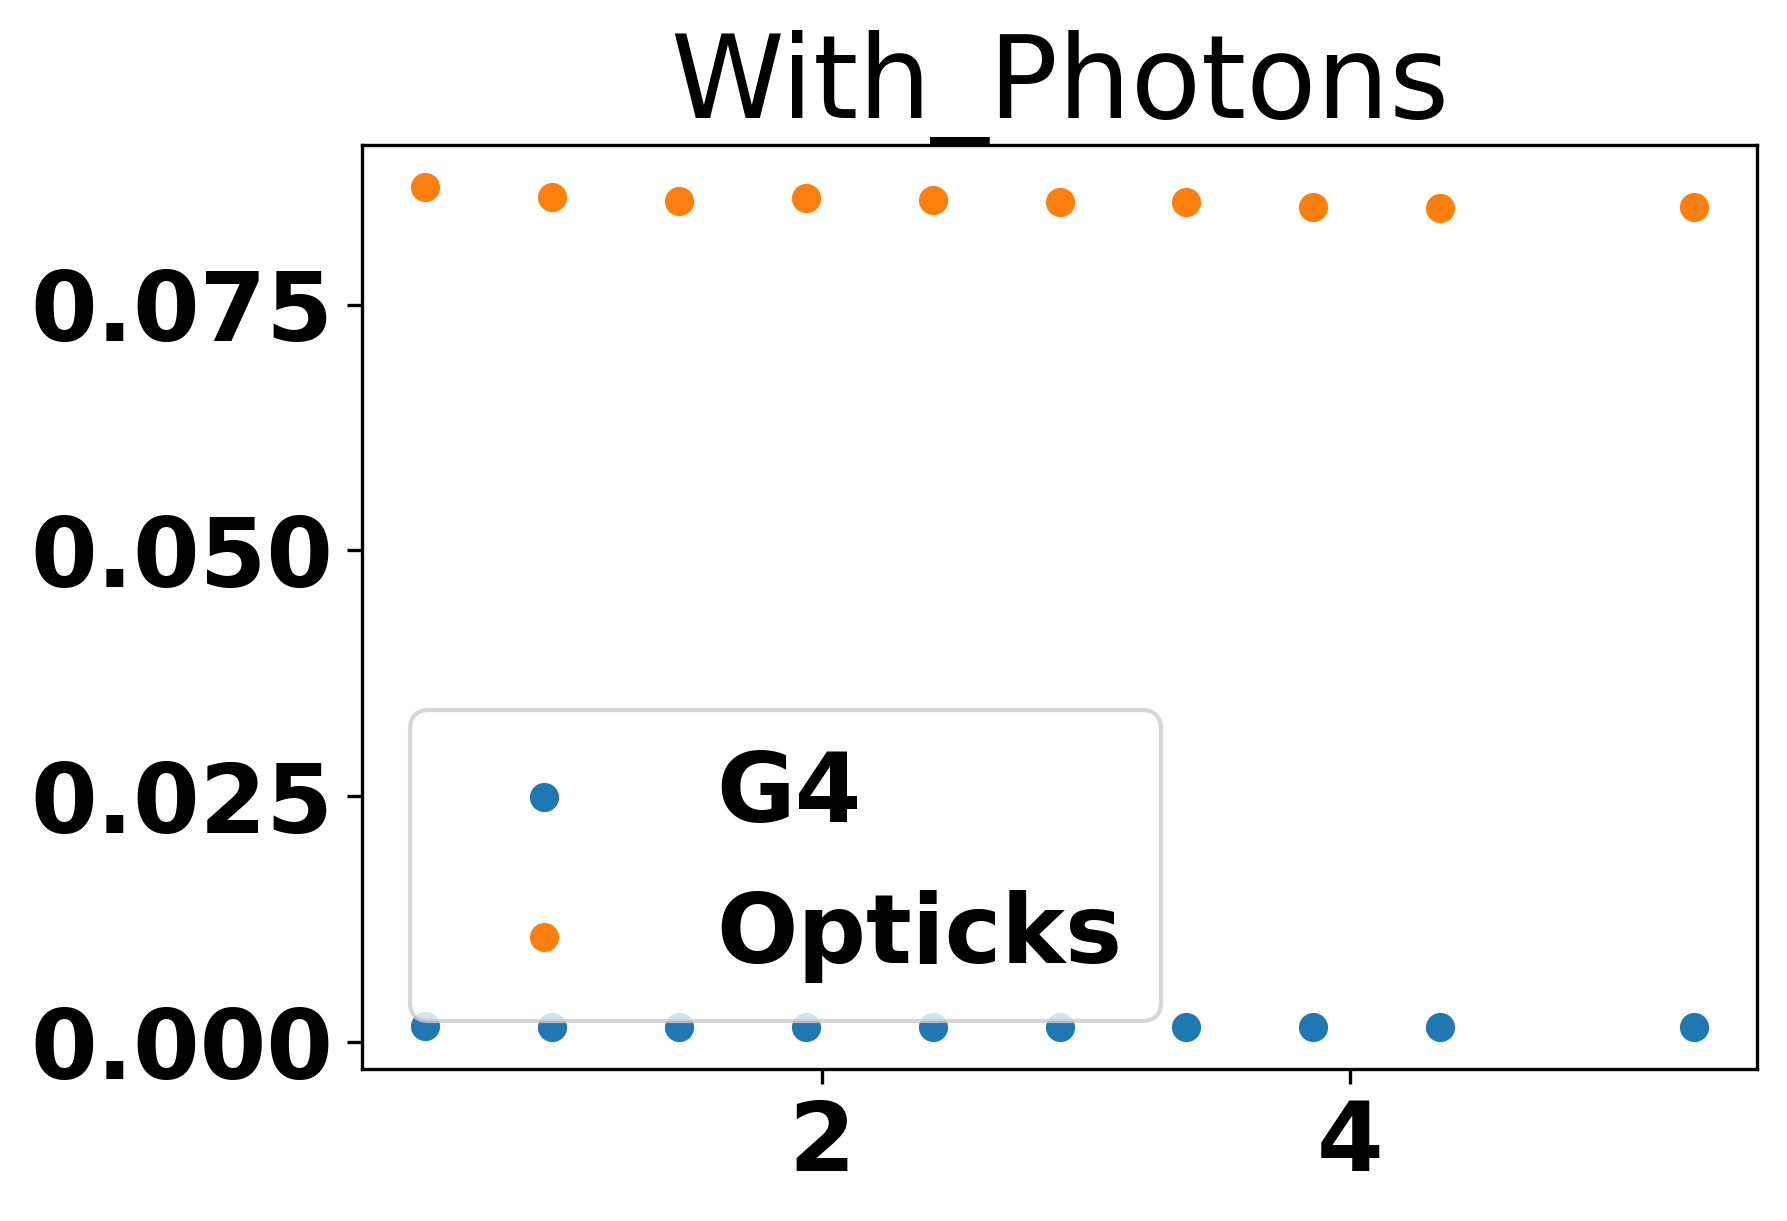

Means [0.15599225 8.55511525] STD [0.0013815  0.05979961]


In [5]:
MainPath="Performance/Laptop/SpeedTest"
paths=[f"{MainPath}/SpeedTest_10Events_G4_10bar_No_EL.h5",f"{MainPath}/SpeedTest_10Events_Opticks_10bar_No_EL.h5",f"{MainPath}/SpeedTest_10Events_G4_10bar.h5",f"{MainPath}/SpeedTest_10Events_Opticks_10bar_Skip0.h5"]
Laptop=Speeds(paths)

# --- Argon-trx40 ----

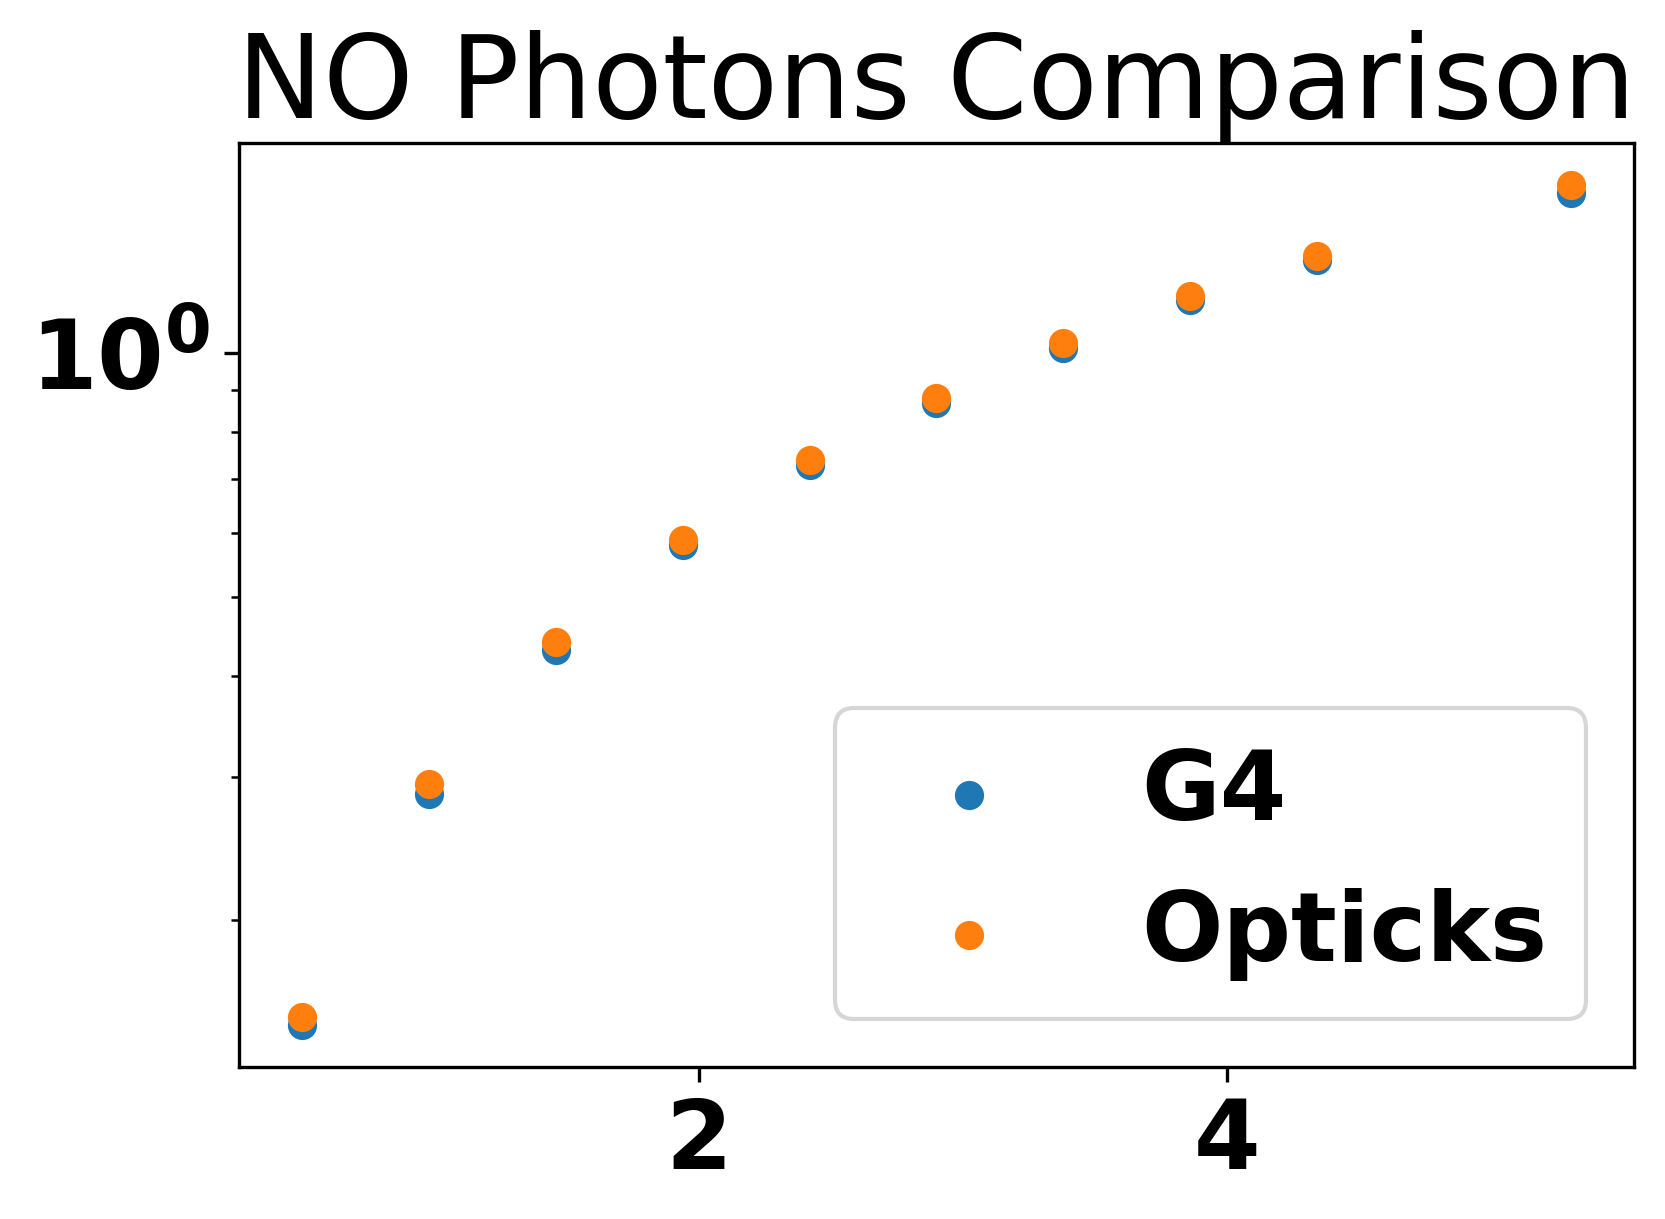

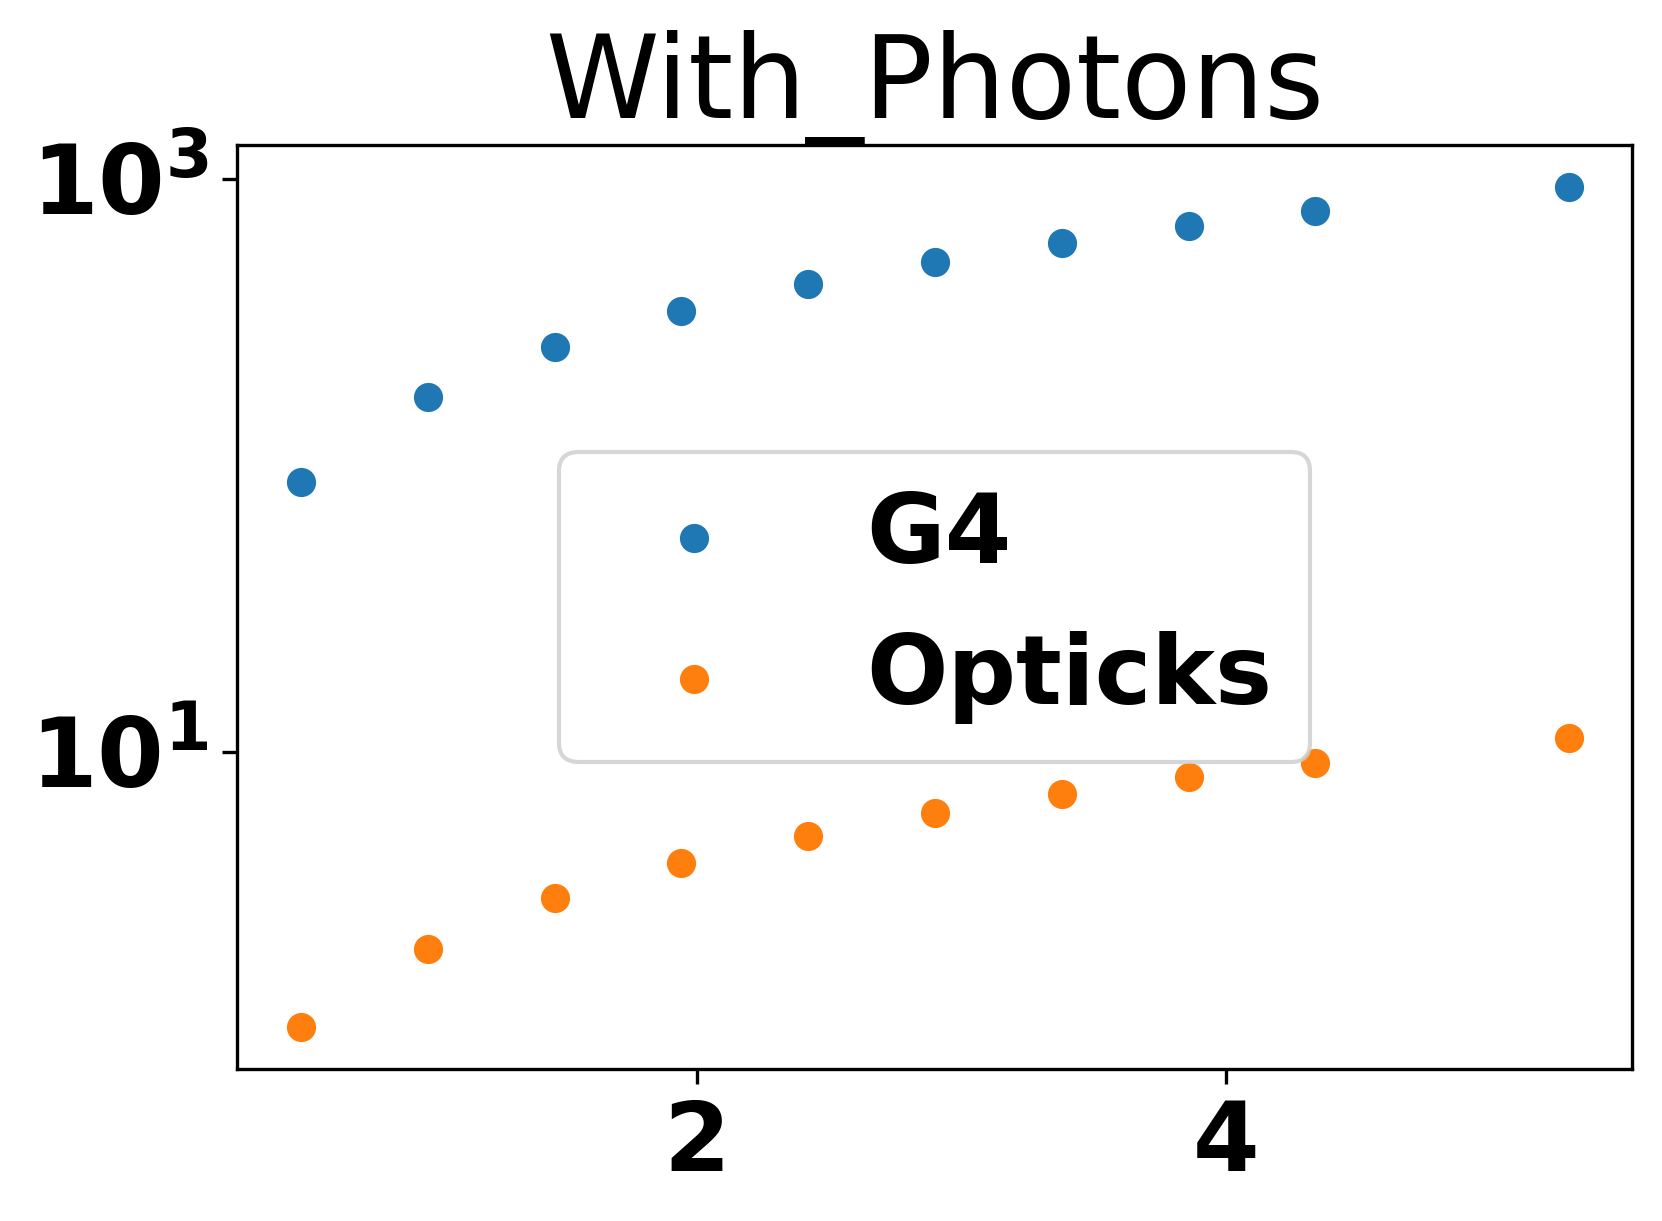

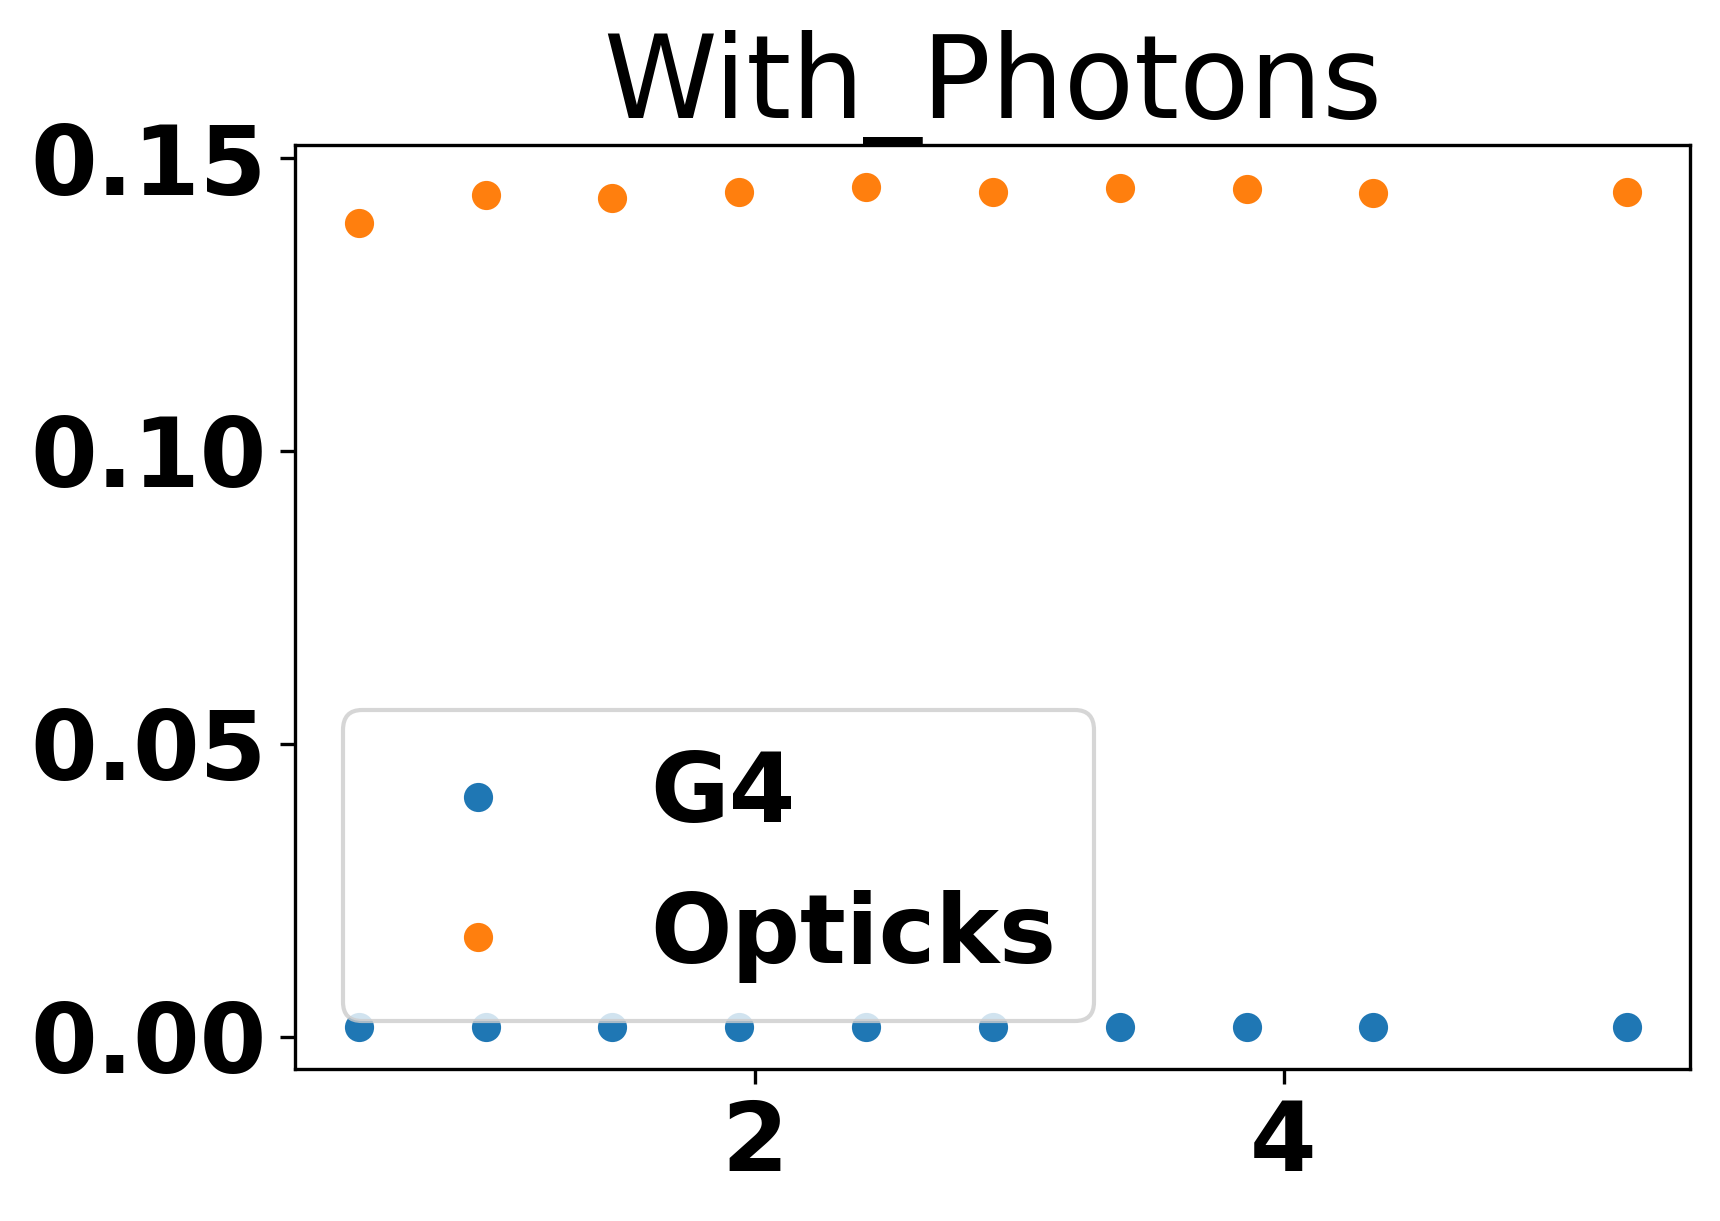

Means [ 0.16874204 14.36686165] STD [0.0015586  0.16907372]


In [6]:
MainPath="Performance/argon-trx40/SpeedTest"
paths=[f"{MainPath}/SpeedTest_10Events_G4_10bar_NoEL.h5",f"{MainPath}/SpeedTest_10Events_Opticks_10bar_NoEL.h5",f"{MainPath}/SpeedTest_10Events_G4_10bar.h5",f"{MainPath}/SpeedTest_10Events_Opticks_10bar.h5"]
Argon_Trx40=Speeds(paths)

In [7]:
Means=np.mean([__3060TI[1][0],Argon_Trx40[1][0],RTX_4090[1][0],Laptop[1]][0])
Std=np.std([__3060TI[1][0],Argon_Trx40[1][0],RTX_4090[1][0],Laptop[1][0]])
print(f"Means {Means} std {Std}")

Means 0.15081997463150232 std 0.0072717485043657356


In [8]:
__3060TI[2]

array([0.00118707, 0.10934809])

In [9]:
G4Percents=np.array([])
G4Percents=np.append(__3060TI[3][0],G4Percents)
G4Percents=np.append(Argon_Trx40[3][0],G4Percents)
G4Percents=np.append(RTX_4090[3][0],G4Percents)
G4Percents=np.append(Laptop[3][0],G4Percents)

OPercents=np.array([])
OPercents=np.append(__3060TI[3][1],OPercents)
OPercents=np.append(Argon_Trx40[3][1],OPercents)
OPercents=np.append(RTX_4090[3][1],OPercents)
OPercents=np.append(Laptop[3][1],OPercents)


G4Means=np.mean(G4Percents)*100
G4Std=np.std([G4Percents])*100
OMean=np.mean(OPercents)*100
OStd=np.std([OPercents])*100
print(f"G4Means {G4Means} std {G4Std}")
print(f"OMeans {OMean} std {OStd}")

G4Means 0.15666193881496351 std 0.007574663009259785
OMeans 15.487663353250078 std 7.234774714787585


In [10]:
G4Percents=np.array([])
G4Percents=np.append(__3060TI[3][0],G4Percents)
G4Percents=np.append(Argon_Trx40[3][0],G4Percents)
G4Percents=np.append(RTX_4090[3][0],G4Percents)
G4Percents=np.append(Laptop[3][0],G4Percents)

OPercents=np.array([])
OPercents=np.append(__3060TI[3][1],OPercents)
OPercents=np.append(Argon_Trx40[3][1],OPercents)
OPercents=np.append(RTX_4090[3][1],OPercents)
OPercents=np.append(Laptop[3][1],OPercents)

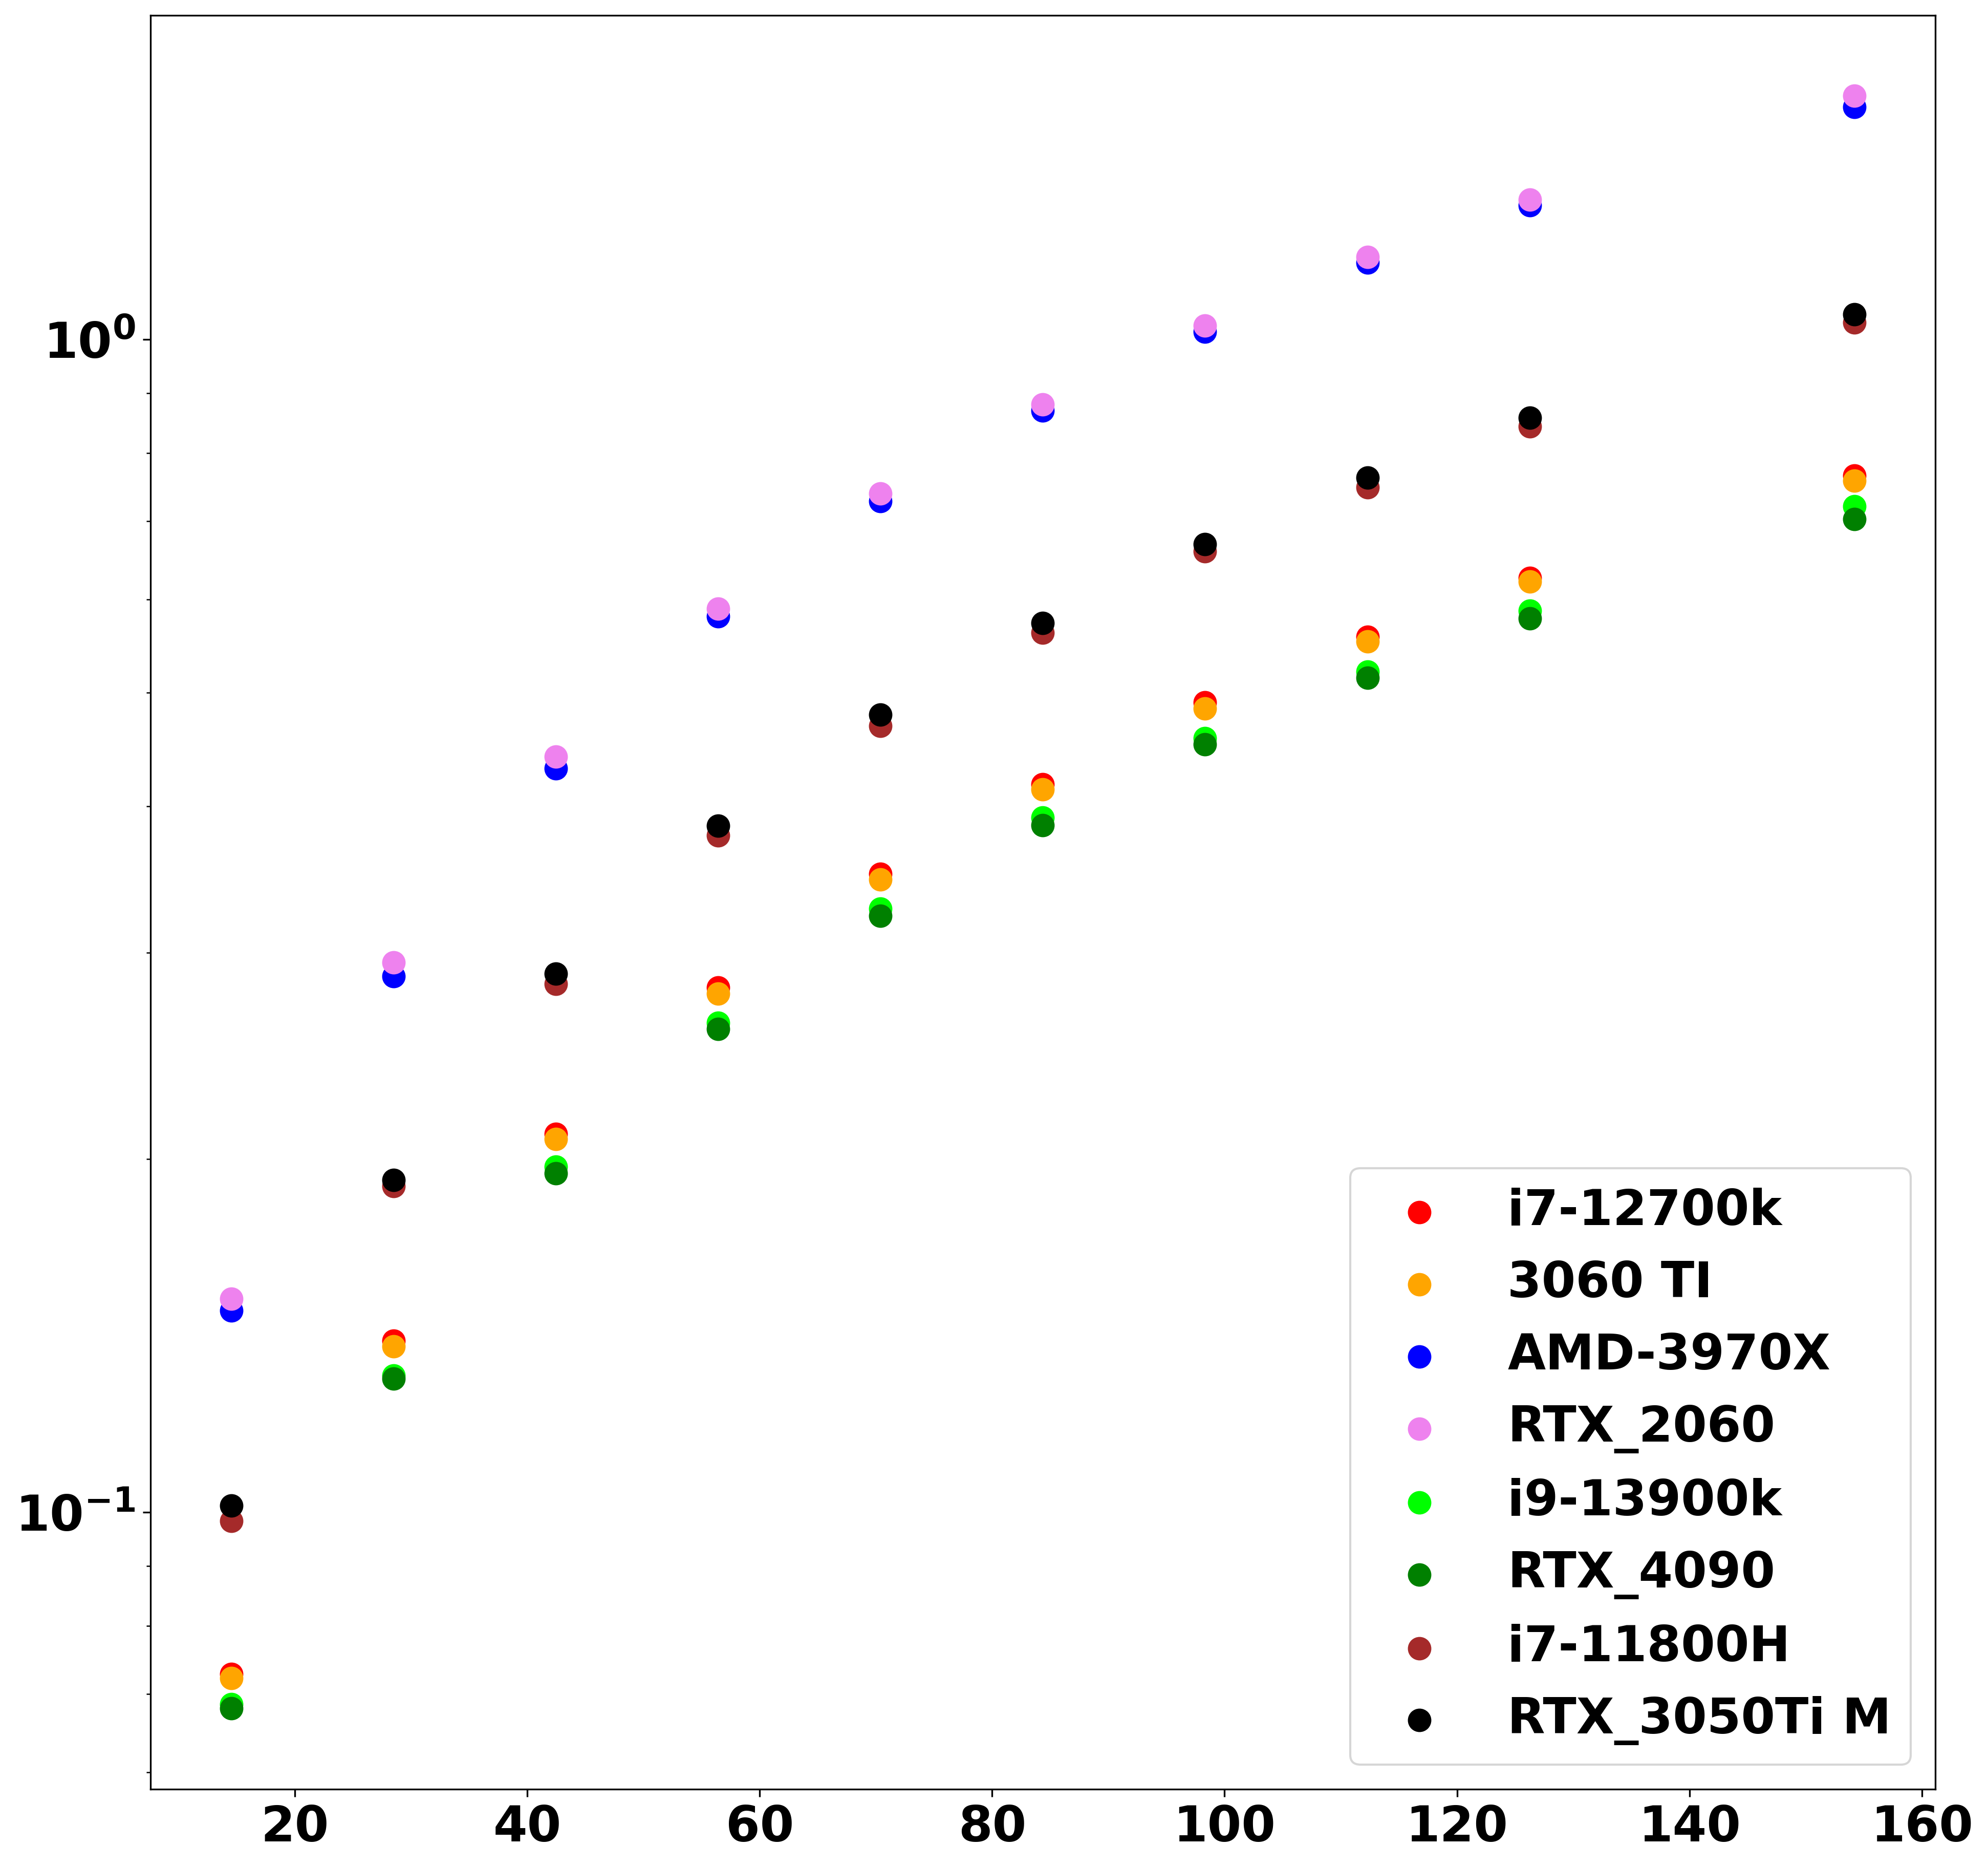

In [11]:
plt.figure(figsize=(15,15),dpi=300)

NumberOfPhotons=__3060TI[0]/22*640
plt.scatter(NumberOfPhotons,__3060TI[4][0],label="i7-12700k",s=100,color="red")
plt.scatter(NumberOfPhotons,__3060TI[4][2],label="3060 TI",s=100,color="orange")
plt.scatter(NumberOfPhotons,Argon_Trx40[4][0],label="AMD-3970X",s=100,color="blue")
plt.scatter(NumberOfPhotons,Argon_Trx40[4][2],label="RTX_2060",s=100,color="violet")
plt.scatter(NumberOfPhotons,RTX_4090[4][0],label="i9-13900k",s=100,color="lime")
plt.scatter(NumberOfPhotons,RTX_4090[4][2],label="RTX_4090",s=100,color="green")
plt.scatter(NumberOfPhotons,Laptop[4][0],label="i7-11800H",s=100,color="brown")
plt.scatter(NumberOfPhotons,Laptop[4][2],label="RTX_3050Ti M",s=100,color="black")
plt.semilogy()
plt.legend()
plt.show()
